In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
print("=" * 60)
print("EDA")
print("=" * 60)

EDA


In [13]:
df = pd.read_csv("data/used_cars.csv")
print(df.shape)
print(f"Dataset have {df.shape[0]} rows and {df.shape[1]} colums")
for col in df.columns:
    print(f"Col: {col}")
    
print(df.info())
print(df.describe().round(2))

(1500, 10)
Dataset have 1500 rows and 10 colums
Col: brand
Col: model_year
Col: mileage_km
Col: engine_size_L
Col: fuel_type
Col: transmission
Col: num_owners
Col: accident_history
Col: service_history
Col: price_usd
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             1500 non-null   object 
 1   model_year        1500 non-null   int64  
 2   mileage_km        1442 non-null   float64
 3   engine_size_L     1432 non-null   float64
 4   fuel_type         1500 non-null   object 
 5   transmission      1500 non-null   object 
 6   num_owners        1500 non-null   int64  
 7   accident_history  1500 non-null   int64  
 8   service_history   1189 non-null   object 
 9   price_usd         1500 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 117.3+ KB
None
       model_year  mileage_km  engine_size_

In [14]:
print("5 first rows")
print(df.head())

5 first rows
     brand  model_year  mileage_km  engine_size_L fuel_type transmission  \
0     Ford        2021     41658.0            2.0    Diesel    Automatic   
1      Kia        2013    151762.0            3.0    Petrol    Automatic   
2    Mazda        2006    200465.0            2.0    Petrol       Manual   
3  Hyundai        2022     38038.0            1.2    Petrol    Automatic   
4    Honda        2013         NaN            1.6    Petrol    Automatic   

   num_owners  accident_history service_history  price_usd  
0           1                 1            Full      30700  
1           3                 0             NaN      19600  
2           2                 0         Partial      14600  
3           2                 0         Partial      31700  
4           2                 0             NaN      26200  


In [39]:
print("Check missing value")
print(df.isnull().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"Column have missing value {col} with {round((df[col].isnull().sum() / len(df) * 100),2)} %")

Check missing value
brand               0
model_year          0
mileage_km          0
engine_size_L       0
fuel_type           0
transmission        0
num_owners          0
accident_history    0
service_history     0
price_usd           0
dtype: int64


In [38]:
df['service_history'] = df['service_history'].fillna("Unknown")
df['mileage_km'] = df['mileage_km'].fillna(df['mileage_km'].median())
df['engine_size_L'] = df['engine_size_L'].fillna(df['engine_size_L'].median())


In [23]:
print("Check duplicate value")
print(df.duplicated().sum())

Check duplicate value
0


In [44]:
numerics_columns = df.select_dtypes(['float64', 'int64']).columns

for col in numerics_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1 
    
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    
    if outliers.sum() > 0:
        print(f"Outliers in {col}: {outliers.sum()}")
    
    # median = df[col].median()
    
    # df[col].apply(
    #     lambda x: median if (x < lower_bound or x > upper_bound) else x 
    # )
    
    df[col] = df[col].clip(lower= lower_bound, upper=upper_bound)

Outliers in mileage_km: 10
Outliers in engine_size_L: 134
Outliers in num_owners: 86


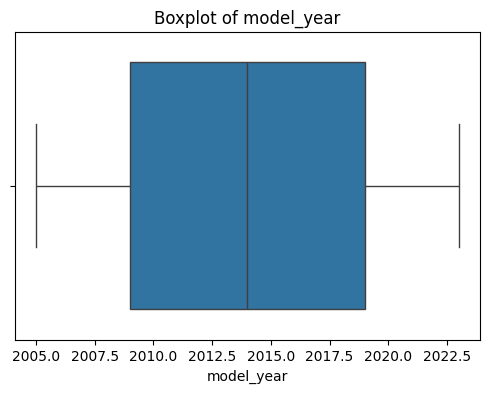

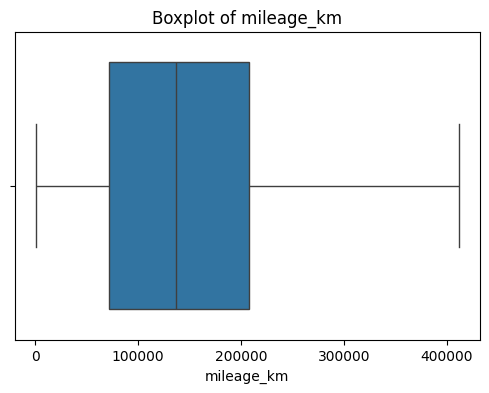

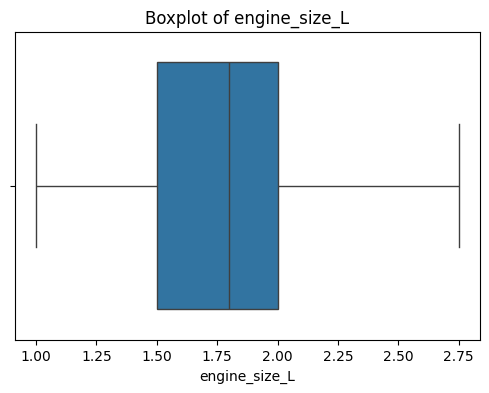

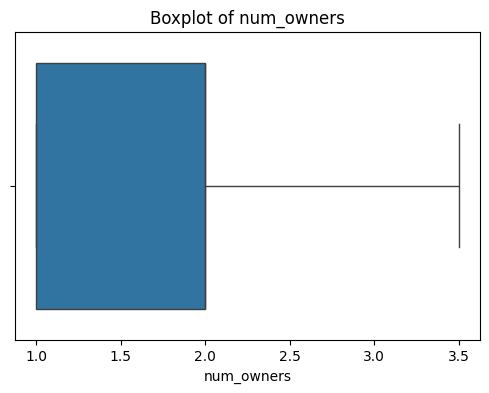

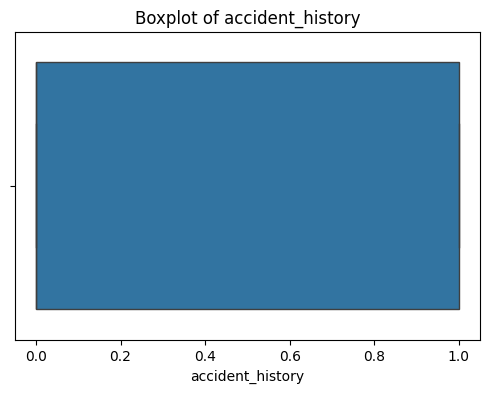

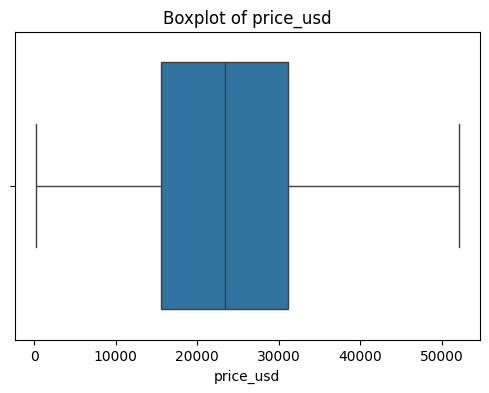

In [45]:
for col in numerics_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    

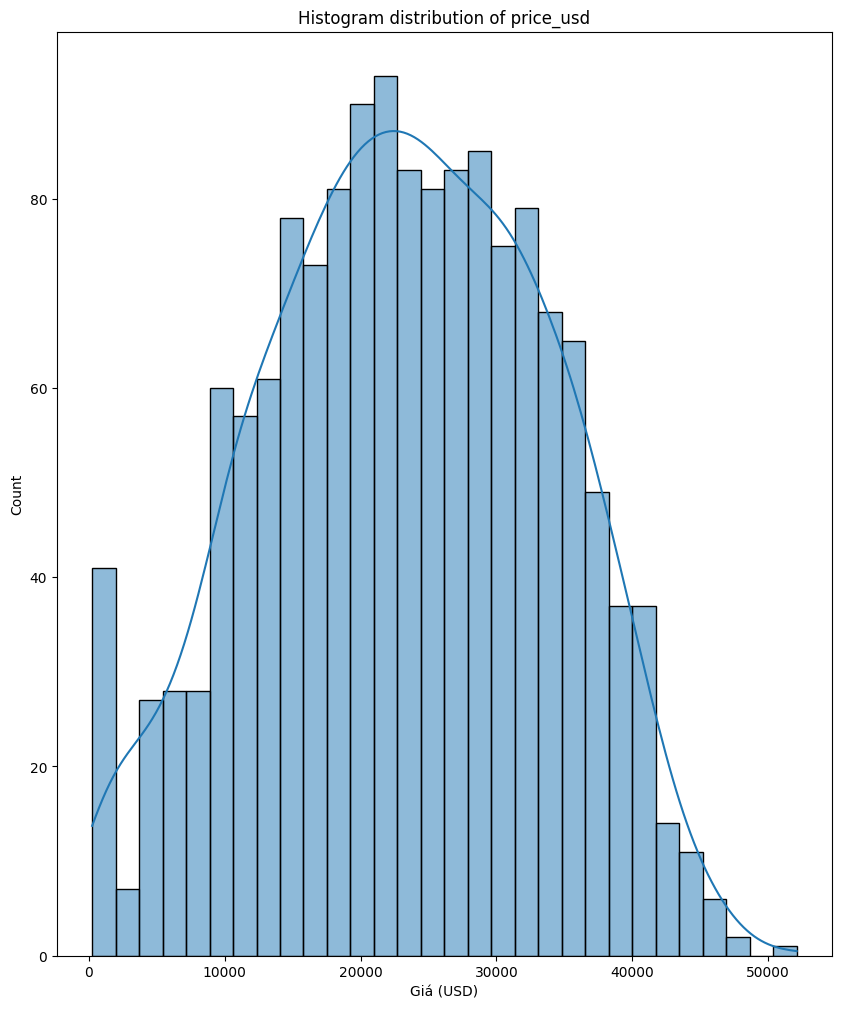

In [47]:
plt.figure(figsize=(10,12))

sns.histplot(
    data = df,
    x ='price_usd',
    kde= True,
    bins = 30,
)
plt.title('Histogram distribution of price_usd')
plt.xlabel('Giá (USD)')
plt.show()

In [48]:
print(df['brand'].value_counts)

<bound method IndexOpsMixin.value_counts of 0          Ford
1           Kia
2         Mazda
3       Hyundai
4         Honda
         ...   
1495    Hyundai
1496    Hyundai
1497        BMW
1498       Ford
1499     Nissan
Name: brand, Length: 1500, dtype: object>


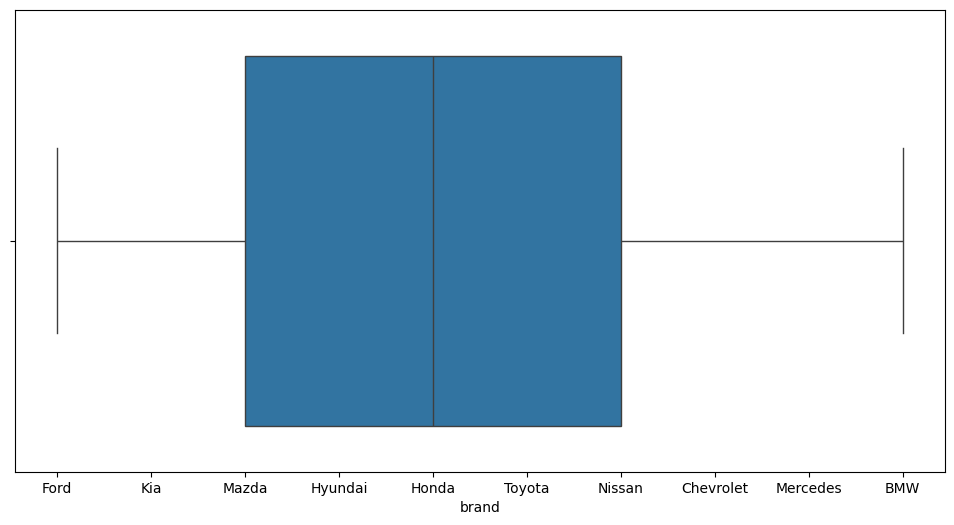

In [52]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data = df,
    x = 'brand'
)
plt.show()

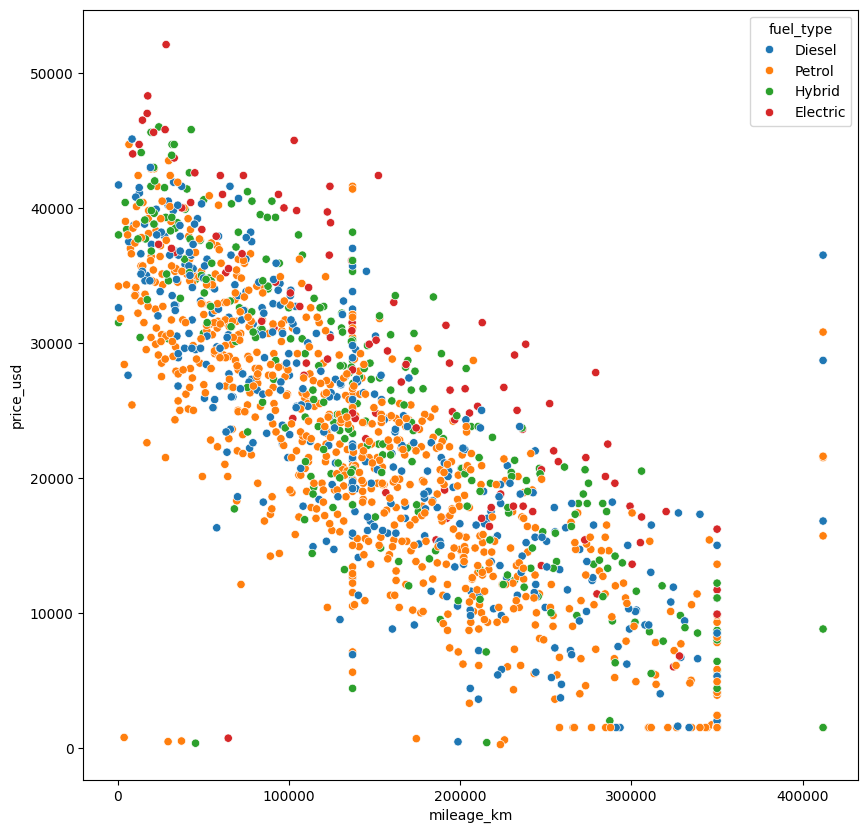

In [56]:
plt.figure(figsize=(10,10))
sns.scatterplot(
    data = df,
    x = "mileage_km",
    y = "price_usd",
    hue = "fuel_type"
)
plt.show()